# Seller Analysis

## Data Loading and Seller-Level Aggregation
We aggregate `master_table.csv` up to one row per `seller_id`, which is the grain this question needs. Two grain decisions matter:

- **Revenue uses `price` (item grain), not `payment_value`.** A seller's revenue is the value of the items they sold. `payment_value` sits at the order grain, so summing it here would attribute a whole multi-item order's value to every seller involved in that order.
- **Review score is averaged over the seller's distinct orders**, not over item rows, so a three-item order does not count three times in the quality measure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/processed/master_table.csv')
print('Row count at item grain:', len(df))

# One row per seller-order, so review_score is not double counted for multi-item orders
df_seller_orders = df.drop_duplicates(subset=['seller_id', 'order_id'])

sellers = df.groupby('seller_id').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique'),
    item_count=('order_item_id', 'count')
).reset_index()

review = df_seller_orders.groupby('seller_id').agg(
    avg_review_score=('review_score', 'mean')
).reset_index()

sellers = sellers.merge(review, on='seller_id')

total_platform_revenue = sellers['total_revenue'].sum()
n_sellers = len(sellers)

print('Sellers:', n_sellers)
print('Sellers with no review at all:', sellers['avg_review_score'].isna().sum())
print(f"Total platform revenue (sum of price): {total_platform_revenue:,.2f}")
print(f"Total seller-orders: {sellers['order_count'].sum():,}")
sellers.head()

Row count at item grain: 112650


Sellers: 3095
Sellers with no review at all: 5
Total platform revenue (sum of price): 13,591,643.70
Total seller-orders: 100,010


,seller_id,total_revenue,order_count,item_count,avg_review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,239,3.984772
2,001e6ad469a905060d959994f1b41e4f,250.00,1,1,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,55,3.901961
4,003554e2dce176b5555353e4f3555ac8,120.00,1,1,5.000000


## GMV Concentration Check
We rank sellers by revenue, build the cumulative share of platform revenue, and read off how much of the business sits inside the top 1%, 5% and 10% of sellers. The dotted diagonal on the plot is what perfect evenness would look like; the further the curve sits above it, the more concentrated the platform is. We also report a Gini coefficient and an HHI so the answer is not left to eyeballing a curve.

In [2]:
conc = sellers.sort_values('total_revenue', ascending=False).reset_index(drop=True)
conc['cum_revenue_share'] = conc['total_revenue'].cumsum() / total_platform_revenue * 100
conc['seller_pct'] = (np.arange(n_sellers) + 1) / n_sellers * 100

print('--- Share of total revenue held by the top X% of sellers ---')
for pct in [1, 5, 10, 20, 50]:
    k = int(np.ceil(n_sellers * pct / 100))
    print(f"Top {pct:>2}% of sellers ({k:>4} sellers) -> {conc.loc[k-1, 'cum_revenue_share']:6.2f}% of revenue")

print(f"\nLargest single seller: {conc.loc[0, 'total_revenue']:,.2f} ({conc.loc[0, 'total_revenue'] / total_platform_revenue * 100:.2f}% of platform revenue)")
print(f"Sellers needed to reach 50% of revenue: {(conc['cum_revenue_share'] < 50).sum() + 1} ({((conc['cum_revenue_share'] < 50).sum() + 1) / n_sellers * 100:.2f}% of sellers)")
print(f"Sellers needed to reach 80% of revenue: {(conc['cum_revenue_share'] < 80).sum() + 1} ({((conc['cum_revenue_share'] < 80).sum() + 1) / n_sellers * 100:.2f}% of sellers)")

sorted_rev = np.sort(conc['total_revenue'].values)
gini = (2 * np.arange(1, n_sellers + 1) - n_sellers - 1).dot(sorted_rev) / (n_sellers * sorted_rev.sum())
hhi = ((conc['total_revenue'] / total_platform_revenue) ** 2).sum()
print(f"\nGini coefficient: {gini:.4f}")
print(f"HHI: {hhi:.6f} (equal revenue across {1 / hhi:.0f} sellers would give the same HHI)")

--- Share of total revenue held by the top X% of sellers ---
Top  1% of sellers (  31 sellers) ->  26.07% of revenue
Top  5% of sellers ( 155 sellers) ->  53.30% of revenue
Top 10% of sellers ( 310 sellers) ->  67.56% of revenue
Top 20% of sellers ( 619 sellers) ->  82.69% of revenue
Top 50% of sellers (1548 sellers) ->  96.79% of revenue

Largest single seller: 229,472.63 (1.69% of platform revenue)
Sellers needed to reach 50% of revenue: 130 (4.20% of sellers)
Sellers needed to reach 80% of revenue: 544 (17.58% of sellers)

Gini coefficient: 0.7915
HHI: 0.003569 (equal revenue across 280 sellers would give the same HHI)


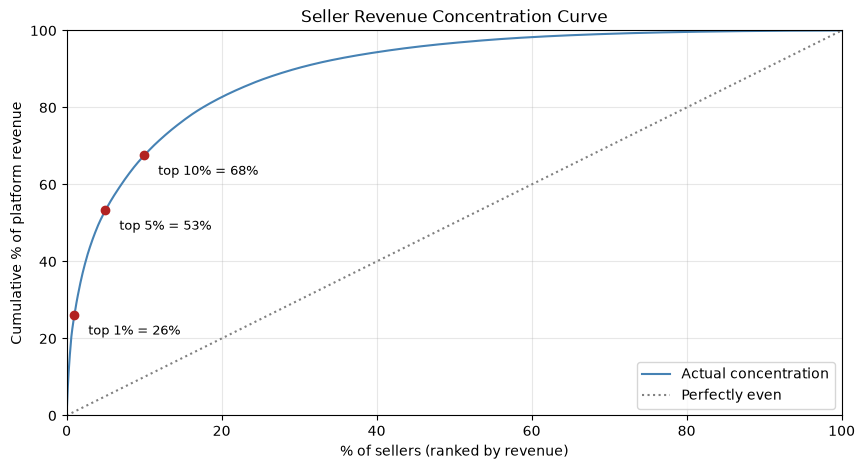

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(conc['seller_pct'], conc['cum_revenue_share'], color='steelblue', label='Actual concentration')
plt.plot([0, 100], [0, 100], color='grey', linestyle=':', label='Perfectly even')

for pct in [1, 5, 10]:
    k = int(np.ceil(n_sellers * pct / 100)) - 1
    plt.scatter(conc.loc[k, 'seller_pct'], conc.loc[k, 'cum_revenue_share'], color='firebrick', zorder=3)
    plt.annotate(f"top {pct}% = {conc.loc[k, 'cum_revenue_share']:.0f}%",
                 (conc.loc[k, 'seller_pct'], conc.loc[k, 'cum_revenue_share']),
                 textcoords='offset points', xytext=(10, -14), fontsize=9)

plt.xlabel('% of sellers (ranked by revenue)')
plt.ylabel('Cumulative % of platform revenue')
plt.title('Seller Revenue Concentration Curve')
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

## Review Quality Variance Across Sellers
Now the quality side. If seller quality were uniform, sellers would pile up around a single average score. The spread of the distribution tells us whether quality is fragmented across the base.

Sellers with at least one review: 3090
Distinct average review scores observed across sellers: 762
Std dev of seller average review score: 0.9558
Platform score weighted by orders: 4.0877
Mean of the per-seller averages:     3.9984


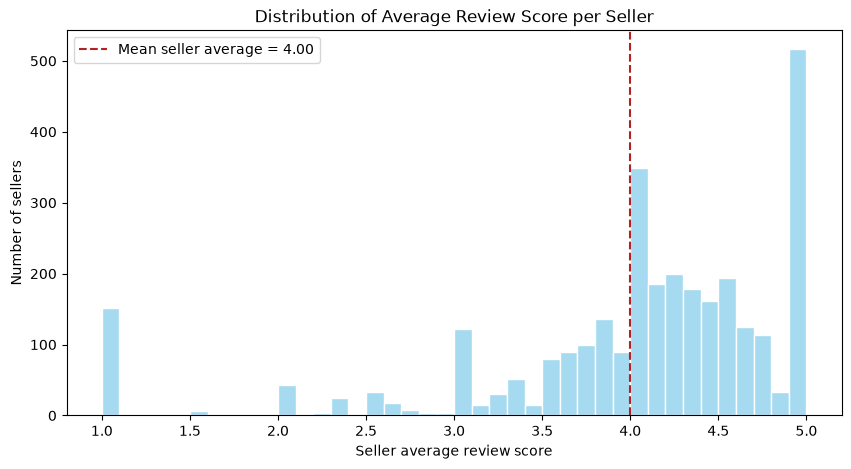

In [4]:
scored = sellers.dropna(subset=['avg_review_score'])

print(f"Sellers with at least one review: {len(scored)}")
print(f"Distinct average review scores observed across sellers: {scored['avg_review_score'].nunique()}")
print(f"Std dev of seller average review score: {scored['avg_review_score'].std():.4f}")
print(f"Platform score weighted by orders: {df_seller_orders['review_score'].mean():.4f}")
print(f"Mean of the per-seller averages:     {scored['avg_review_score'].mean():.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scored['avg_review_score'], bins=40, color='skyblue', edgecolor='white')
plt.axvline(scored['avg_review_score'].mean(), color='firebrick', linestyle='--',
            label=f"Mean seller average = {scored['avg_review_score'].mean():.2f}")
plt.title('Distribution of Average Review Score per Seller')
plt.xlabel('Seller average review score')
plt.ylabel('Number of sellers')
plt.legend()
plt.show()

## Low-Score Sellers: One Bad Review vs. A Sustained Quality Problem
A seller with one order and one 1-star review is not evidence of a quality problem — it is one unhappy customer. The same average score from a seller with 50 orders is a completely different signal. So we take every seller averaging below 3.0 and re-cut them by how many distinct orders they actually have, which separates statistical noise from a sustained problem.

In [5]:
LOW_SCORE = 3.0
low = sellers[sellers['avg_review_score'] < LOW_SCORE]
low_revenue_share = low['total_revenue'].sum() / total_platform_revenue * 100

print(f"--- Sellers averaging below {LOW_SCORE} ---")
print(f"Count: {len(low)} ({len(low) / n_sellers * 100:.2f}% of sellers)")
print(f"Revenue held: {low['total_revenue'].sum():,.2f} ({low_revenue_share:.2f}% of platform revenue)")
print(f"Median order count among them: {low['order_count'].median():.0f}")

print('\n--- Re-cut by genuine order volume (cumulative thresholds) ---')
noise_vs_problem = []
for min_orders in [1, 2, 5, 10, 20]:
    bucket = low[low['order_count'] >= min_orders]
    noise_vs_problem.append({
        'min_orders': min_orders,
        'sellers': len(bucket),
        'pct_of_all_low_scorers': len(bucket) / len(low) * 100,
        'total_revenue': bucket['total_revenue'].sum(),
        'pct_of_platform_revenue': bucket['total_revenue'].sum() / total_platform_revenue * 100,
    })
    print(f"  >= {min_orders:>2} orders: {len(bucket):>4} sellers, {bucket['total_revenue'].sum():>11,.2f} revenue ({bucket['total_revenue'].sum() / total_platform_revenue * 100:.2f}% of platform)")

print(f"\nSellers with exactly 1 order in the whole base: {(sellers['order_count'] == 1).sum()} ({(sellers['order_count'] == 1).mean() * 100:.2f}%)")
print(f"Low scorers sitting on a single order: {len(low[low['order_count'] == 1])} of {len(low)}")

--- Sellers averaging below 3.0 ---
Count: 305 (9.85% of sellers)
Revenue held: 333,129.62 (2.45% of platform revenue)
Median order count among them: 2

--- Re-cut by genuine order volume (cumulative thresholds) ---
  >=  1 orders:  305 sellers,  333,129.62 revenue (2.45% of platform)
  >=  2 orders:  168 sellers,  303,043.10 revenue (2.23% of platform)
  >=  5 orders:   48 sellers,  214,080.91 revenue (1.58% of platform)
  >= 10 orders:   20 sellers,  153,506.92 revenue (1.13% of platform)
  >= 20 orders:    7 sellers,   80,388.12 revenue (0.59% of platform)

Sellers with exactly 1 order in the whole base: 571 (18.45%)
Low scorers sitting on a single order: 137 of 305


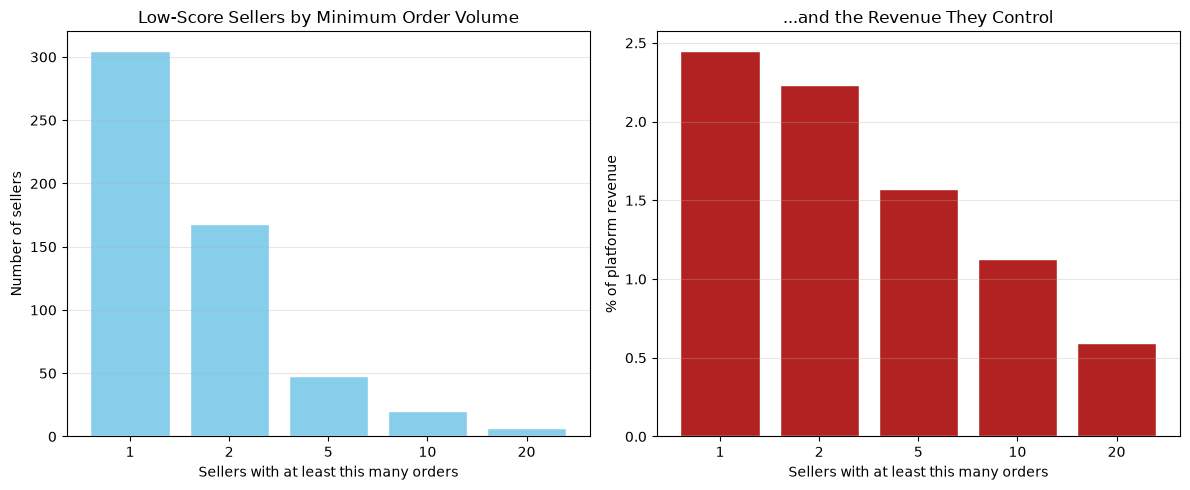

In [6]:
nvp = pd.DataFrame(noise_vs_problem)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(nvp['min_orders'].astype(str), nvp['sellers'], color='skyblue', edgecolor='white')
axes[0].set_title('Low-Score Sellers by Minimum Order Volume')
axes[0].set_xlabel('Sellers with at least this many orders')
axes[0].set_ylabel('Number of sellers')
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].bar(nvp['min_orders'].astype(str), nvp['pct_of_platform_revenue'], color='firebrick', edgecolor='white')
axes[1].set_title('...and the Revenue They Control')
axes[1].set_xlabel('Sellers with at least this many orders')
axes[1].set_ylabel('% of platform revenue')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Volume vs. Quality Relationship
The next question is whether quality holds as sellers scale. Order volume here is extremely skewed (a few sellers have over a thousand orders, most have one or two), so we report a rank correlation and a log-scale correlation alongside the raw Pearson coefficient — a raw Pearson on a variable this skewed is not trustworthy on its own.

In [7]:
print('--- Correlation between order volume and average review score ---')
print(f"Pearson  (order_count vs avg_review_score):       {sellers['order_count'].corr(sellers['avg_review_score']):.4f}")
print(f"Spearman (order_count vs avg_review_score):       {sellers['order_count'].corr(sellers['avg_review_score'], method='spearman'):.4f}")
print(f"Pearson  (log10 order_count vs avg_review_score): {np.log10(sellers['order_count']).corr(sellers['avg_review_score']):.4f}")

sellers['volume_bucket'] = pd.cut(
    sellers['order_count'],
    bins=[0, 1, 5, 20, 100, np.inf],
    labels=['1 order', '2-5 orders', '6-20 orders', '21-100 orders', '100+ orders']
)

print('\n--- Average review score by seller volume bucket ---')
print(sellers.groupby('volume_bucket', observed=True).agg(
    sellers=('seller_id', 'count'),
    avg_review_score=('avg_review_score', 'mean'),
    total_revenue=('total_revenue', 'sum')
).round(4))

print('\n--- Share of platform revenue by bucket ---')
print((sellers.groupby('volume_bucket', observed=True)['total_revenue'].sum() / total_platform_revenue * 100).round(2))

--- Correlation between order volume and average review score ---
Pearson  (order_count vs avg_review_score):       0.0285
Spearman (order_count vs avg_review_score):       -0.1020
Pearson  (log10 order_count vs avg_review_score): 0.1221

--- Average review score by seller volume bucket ---
               sellers  avg_review_score  total_revenue
volume_bucket                                          
1 order            571            3.7915      133042.75
2-5 orders         872            3.9228      607741.87
6-20 orders        854            4.0990     1759919.73
21-100 orders      588            4.1311     4093391.93
100+ orders        210            4.0900     6997547.42

--- Share of platform revenue by bucket ---
volume_bucket
1 order           0.98
2-5 orders        4.47
6-20 orders      12.95
21-100 orders    30.12
100+ orders      51.48
Name: total_revenue, dtype: float64


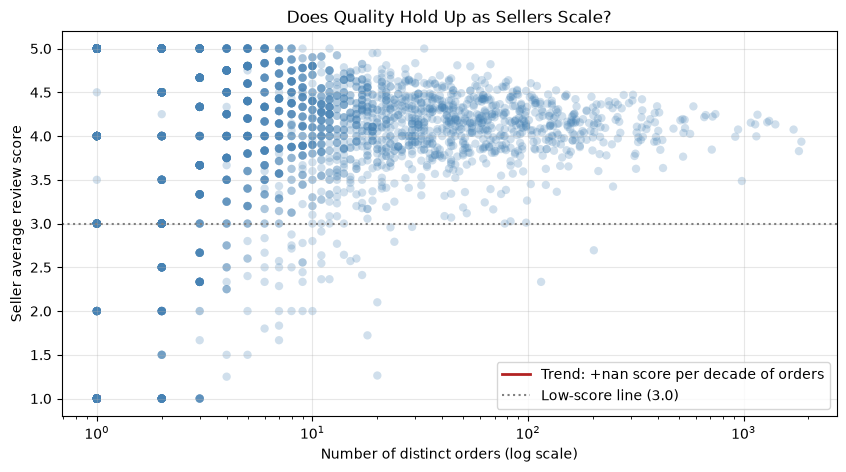

In [8]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=sellers, x='order_count', y='avg_review_score', alpha=0.25, color='steelblue', edgecolor='none')
plt.xscale('log')

# Fit the trend in log space, which is where the volume distribution is roughly symmetric
z = np.polyfit(np.log10(sellers['order_count']), sellers['avg_review_score'], 1)
xs = np.linspace(0, np.log10(sellers['order_count'].max()), 50)
plt.plot(10 ** xs, np.polyval(z, xs), color='firebrick', linewidth=2,
         label=f'Trend: {z[0]:+.3f} score per decade of orders')

plt.axhline(LOW_SCORE, color='grey', linestyle=':', label=f'Low-score line ({LOW_SCORE})')
plt.xlabel('Number of distinct orders (log scale)')
plt.ylabel('Seller average review score')
plt.title('Does Quality Hold Up as Sellers Scale?')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

## Seller Segmentation: Volume vs. Quality (2x2)
We cut sellers on the two axes that matter operationally. Volume is split at the median seller (7 distinct orders); quality is split at the platform mean average score. Sellers with no reviews at all are excluded from the quality cut — they have revenue but no quality signal, and dropping them into "low quality" would be a mislabel. The high-volume / low-quality quadrant is the one worth flagging: bad service at scale, where the revenue is actually at stake.

In [9]:
seg_base = sellers.dropna(subset=['avg_review_score']).copy()
unrated_revenue = sellers['total_revenue'].sum() - seg_base['total_revenue'].sum()
print(f"Excluded {sellers['avg_review_score'].isna().sum()} sellers with no reviews ({unrated_revenue:,.2f} revenue, {unrated_revenue / total_platform_revenue * 100:.2f}% of platform) from the quality cut.")

vol_cut = seg_base['order_count'].median()
qual_cut = seg_base['avg_review_score'].mean()
print(f"\nVolume cut: {vol_cut:.0f} distinct orders (the median seller)")
print(f"Quality cut: {qual_cut:.2f} average review score (the platform mean)")

seg_base['volume_segment'] = np.where(seg_base['order_count'] > vol_cut, 'High volume', 'Low volume')
seg_base['quality_segment'] = np.where(seg_base['avg_review_score'] >= qual_cut, 'High quality', 'Low quality')

segments = seg_base.groupby(['volume_segment', 'quality_segment']).agg(
    sellers=('seller_id', 'count'),
    total_revenue=('total_revenue', 'sum'),
    total_orders=('order_count', 'sum'),
    avg_review_score=('avg_review_score', 'mean')
).reset_index()
segments['pct_of_sellers'] = segments['sellers'] / len(seg_base) * 100
segments['pct_of_revenue'] = segments['total_revenue'] / seg_base['total_revenue'].sum() * 100

print('\n--- 2x2 Segmentation ---')
print(segments.round(2).to_string(index=False))

risk = segments[(segments['volume_segment'] == 'High volume') & (segments['quality_segment'] == 'Low quality')]
print(f"\nRisk segment (high volume / low quality): {int(risk['sellers'].iloc[0])} sellers, {risk['pct_of_revenue'].iloc[0]:.2f}% of revenue, {risk['total_orders'].iloc[0]:,} orders")

Excluded 5 sellers with no reviews (7,657.80 revenue, 0.06% of platform) from the quality cut.

Volume cut: 7 distinct orders (the median seller)
Quality cut: 4.00 average review score (the platform mean)

--- 2x2 Segmentation ---
volume_segment quality_segment  sellers  total_revenue  total_orders  avg_review_score  pct_of_sellers  pct_of_revenue
   High volume    High quality      990     8750764.00         64670              4.33           32.04           64.42
   High volume     Low quality      451     3832044.89         30693              3.63           14.60           28.21
    Low volume    High quality     1068      597783.78          3013              4.65           34.56            4.40
    Low volume     Low quality      581      403393.23          1629              2.51           18.80            2.97

Risk segment (high volume / low quality): 451 sellers, 28.21% of revenue, 30,693 orders


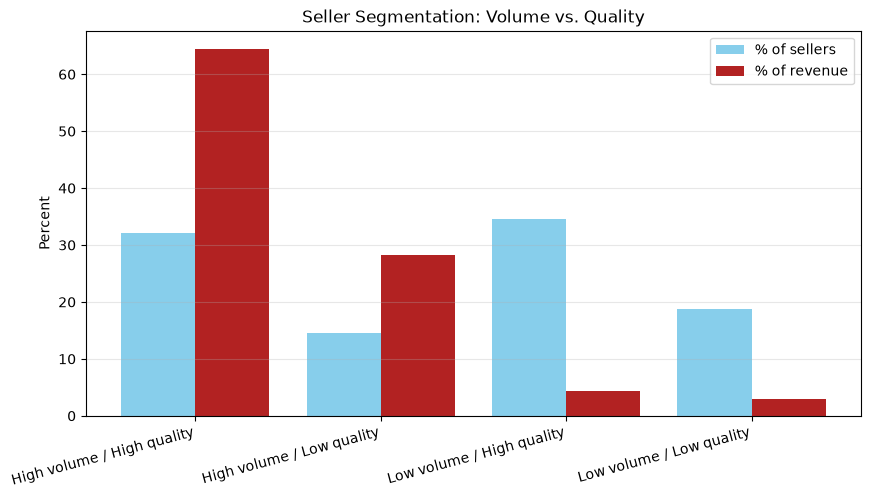

In [10]:
plot_df = segments.copy()
plot_df['segment'] = plot_df['volume_segment'] + ' / ' + plot_df['quality_segment']
x_pos = np.arange(len(plot_df))

plt.figure(figsize=(10, 5))
plt.bar(x_pos - 0.2, plot_df['pct_of_sellers'], width=0.4, label='% of sellers', color='skyblue')
plt.bar(x_pos + 0.2, plot_df['pct_of_revenue'], width=0.4, label='% of revenue', color='firebrick')
plt.xticks(x_pos, plot_df['segment'], rotation=15, ha='right')
plt.ylabel('Percent')
plt.title('Seller Segmentation: Volume vs. Quality')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## Scope Limitation: The Fifth Hypothesis (Credit & Payment Risk) Is Not Testable Here

This needs to be stated plainly rather than worked around.

The original fifth hypothesis was **credit & payment risk** — essentially, does the way a customer pays predict financial exposure? The dataset contains `payment_type` (credit card, boleto, voucher, debit card, etc.) and `payment_installments`, so it is tempting to treat multi-installment or boleto payment as a proxy for credit risk.

It is not a proxy. **The dataset contains no loan origination, no repayment behaviour, no delinquency, no default and no chargeback outcomes at all.** There is no label to predict and no outcome to correlate against. `payment_installments` tells us how many times a charge was split, which is a checkout behaviour, not a credit outcome — a customer paying in 10 installments is not the same event as a customer defaulting, and the two are not linked anywhere in the data.

Treating payment method as a stand-in for credit risk would produce a confident-looking number with no empirical basis behind it, so this hypothesis is declared **out of scope for this dataset** rather than approximated. Testing it properly would require a credit bureau, lending, or chargeback dataset joined to these orders on `customer_unique_id`.

## Summary Findings
- **Revenue is moderately concentrated, not dangerously so.** The top 1% of sellers (31) take 26% of platform revenue, the top 5% (155) take 53% and the top 10% (310) take 68%, with a Gini of 0.79. Concentration is real — just 130 sellers (4.2% of the base) account for half of all revenue — but it is a long tail rather than a monopoly: no single seller exceeds 1.7% of revenue, so losing any one of them is survivable.
- **Seller quality is genuinely fragmented at the tail.** 305 sellers (9.9%) average below 3.0, and seller averages are spread across 762 distinct values instead of clustering. However those sellers hold only 2.5% of revenue and the median one has just 2 orders. Filtering to sellers with real volume leaves only 48 low scorers with 5+ orders (1.6% of revenue) and 7 with 20+ orders (0.6%) — so most of the low scores are small-sample noise, not a broad quality collapse.
- **The exposure that actually matters is bad service at scale, not in the tail.** 451 sellers (14.6% of rated sellers) run above-median volume with a below-average score, and between them they control **28.2% of platform revenue** across 30,693 orders. This is the segment to flag.
- **Quality holds up as sellers scale, it does not degrade.** The log-scale trend is mildly positive (+0.12 per decade) and average score rises from 3.79 for single-order sellers to 4.13 at 21-100 orders before flattening at 4.09 for the 100+ sellers. The raw Pearson of +0.03 is uninformative only because order volume is heavily skewed, and the negative Spearman (-0.10) is an artifact of the single-order tail.
- **The takeaway for a business stakeholder:** the supplier base is diversified enough that seller loss is not a platform-level risk, but roughly 28% of revenue sits with sellers who underperform on the only quality signal available, while 1,443 sellers (47%) have five or fewer orders and contribute almost nothing. The action is targeted quality remediation on the high-volume/low-quality segment, plus scaling the high-volume/high-quality group that already holds 64% of revenue — not a broad seller purge, and explicitly not any action on credit risk, which this dataset cannot measure.

## Validation Check: Seller Problem, or Delivery Problem in Disguise?

The risk segment above is defined purely on review score, so it is mixing two potentially different situations: sellers whose product or service quality is genuinely poor, and sellers who are fine but systematically miss delivery dates — where the score is punishing the logistics, not the seller. We rebuild notebook 12's `is_late` flag at the order grain, roll it up to each seller, and merge it into the segmentation table to see which explanation the data supports.

In [11]:
# Rebuild notebook 12's lateness flag at the order grain
orders = df.drop_duplicates(subset=['order_id']).copy()
for col in ['order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col])

delivered = orders.dropna(subset=['order_delivered_customer_date']).copy()
delivered['delivery_delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['is_late'] = delivered['delivery_delay_days'] > 0

platform_late_rate = delivered['is_late'].mean() * 100
platform_ontime_score = delivered.loc[~delivered['is_late'], 'review_score'].mean()
platform_late_score = delivered.loc[delivered['is_late'], 'review_score'].mean()

print(f"Excluded {orders['order_delivered_customer_date'].isnull().sum()} orders with no delivery date, matching notebook 12.")
print(f"Platform late rate: {platform_late_rate:.2f}%  (on-time score {platform_ontime_score:.2f} vs late score {platform_late_score:.2f})")

# Late rate across each seller's own delivered orders
late_by_seller = delivered.groupby('seller_id').agg(
    late_rate=('is_late', 'mean'),
    delivered_orders=('is_late', 'size')
).reset_index()

seg_base['segment'] = seg_base['volume_segment'] + ' / ' + seg_base['quality_segment']
seg_base = seg_base.merge(late_by_seller, on='seller_id', how='left')
print(f"Sellers with no delivered order at all (no late rate available): {seg_base['late_rate'].isna().sum()}")

segment_late = seg_base.groupby('segment').agg(
    sellers=('seller_id', 'count'),
    delivered_orders=('delivered_orders', 'sum'),
    late_rate=('late_rate', 'mean'),
    avg_review_score=('avg_review_score', 'mean'),
    total_revenue=('total_revenue', 'sum')
).round(4)
segment_late['pct_of_revenue'] = segment_late['total_revenue'] / segment_late['total_revenue'].sum() * 100

print('\n--- Late-delivery rate by segment ---')
print(segment_late.sort_values('late_rate', ascending=False).to_string())
print(f"\nPlatform late rate for comparison: {platform_late_rate:.2f}%")

Excluded 2190 orders with no delivery date, matching notebook 12.
Platform late rate: 6.77%  (on-time score 4.29 vs late score 2.27)
Sellers with no delivered order at all (no late rate available): 133

--- Late-delivery rate by segment ---
                            sellers  delivered_orders  late_rate  avg_review_score  total_revenue  pct_of_revenue
segment                                                                                                          
Low volume / Low quality        581            1266.0     0.1706            2.5116      403393.23        2.969623
High volume / Low quality       451           29237.0     0.1064            3.6282     3832044.89       28.210018
High volume / High quality      990           63022.0     0.0498            4.3346     8750764.00       64.419708
Low volume / High quality      1068            2948.0     0.0279            4.6520      597783.78        4.400651

Platform late rate for comparison: 6.77%


In [12]:
# The sharper test: is the on-time vs late drop inside this segment the same drop we see everywhere?
delivered_seg = delivered.merge(seg_base[['seller_id', 'segment']], on='seller_id', how='inner')

gap_check = pd.DataFrame({
    'ontime_score': delivered_seg[~delivered_seg['is_late']].groupby('segment')['review_score'].mean(),
    'late_score': delivered_seg[delivered_seg['is_late']].groupby('segment')['review_score'].mean(),
    'orders': delivered_seg.groupby('segment').size(),
    'late_orders': delivered_seg.groupby('segment')['is_late'].sum(),
})
gap_check['overall_score'] = delivered_seg.groupby('segment')['review_score'].mean()
gap_check['gap'] = gap_check['ontime_score'] - gap_check['late_score']

print(f"Platform-wide benchmark: on-time {platform_ontime_score:.2f}, late {platform_late_score:.2f}, gap {platform_ontime_score - platform_late_score:.2f}")
print('\n--- Review score on on-time vs late orders, within each segment ---')
print(gap_check.round(3).to_string())

RISK = 'High volume / Low quality'
HQ = 'High volume / High quality'
risk = delivered_seg[delivered_seg['segment'] == RISK]

print(f"\n{RISK} segment average score {gap_check.loc[RISK, 'overall_score']:.2f} vs {HQ} {gap_check.loc[HQ, 'overall_score']:.2f}")
print(f"  its on-time orders score {gap_check.loc[RISK, 'ontime_score']:.2f}, against {platform_ontime_score:.2f} platform-wide on-time")
print(f"  its late orders score    {gap_check.loc[RISK, 'late_score']:.2f}, against {platform_late_score:.2f} platform-wide late")

# Counterfactual: what if every late order in this segment had scored like a normal on-time order?
lifted = risk['review_score'].where(~risk['is_late'], platform_ontime_score).mean()
deficit = gap_check.loc[HQ, 'overall_score'] - gap_check.loc[RISK, 'overall_score']
lift = lifted - gap_check.loc[RISK, 'overall_score']
print(f"\nIf its {int(risk['is_late'].sum()):,} late orders had scored like on-time orders elsewhere, the segment would move "
      f"{gap_check.loc[RISK, 'overall_score']:.2f} -> {lifted:.2f}")
print(f"That recovers {lift:.2f} of its {deficit:.2f} score deficit vs the high-volume/high-quality segment, so roughly "
      f"{lift / deficit * 100:.0f}% of the gap is delivery-driven and {100 - lift / deficit * 100:.0f}% survives it")
print(f"For scale, this segment alone generates {int(risk['is_late'].sum()):,} of the {int(delivered['is_late'].sum()):,} late orders on the whole platform "
      f"({risk['is_late'].sum() / delivered['is_late'].sum() * 100:.0f}%) while holding {segment_late.loc[RISK, 'pct_of_revenue']:.1f}% of revenue")

# Cleanest possible test: risk sellers who never miss a delivery date at all
never_late = seg_base[(seg_base['segment'] == RISK) & (seg_base['late_rate'] == 0)]
print(f"\nSanity check — {len(never_late)} of the {int((seg_base['segment'] == RISK).sum())} risk-segment sellers have a 0% late rate, and they still average "
      f"{never_late['avg_review_score'].mean():.2f} against a platform on-time average of {platform_ontime_score:.2f}")

Platform-wide benchmark: on-time 4.29, late 2.27, gap 2.02

--- Review score on on-time vs late orders, within each segment ---
                            ontime_score  late_score  orders  late_orders  overall_score    gap
segment                                                                                        
High volume / High quality         4.403       2.368   63022         3569          4.290  2.035
High volume / Low quality          4.028       2.135   29237         2685          3.857  1.893
Low volume / High quality          4.638       3.247    2948           97          4.594  1.391
Low volume / Low quality           3.588       1.887    1266          181          3.348  1.701

High volume / Low quality segment average score 3.86 vs High volume / High quality 4.29
  its on-time orders score 4.03, against 4.29 platform-wide on-time
  its late orders score    2.14, against 2.27 platform-wide late

If its 2,685 late orders had scored like on-time orders elsewhere, the se

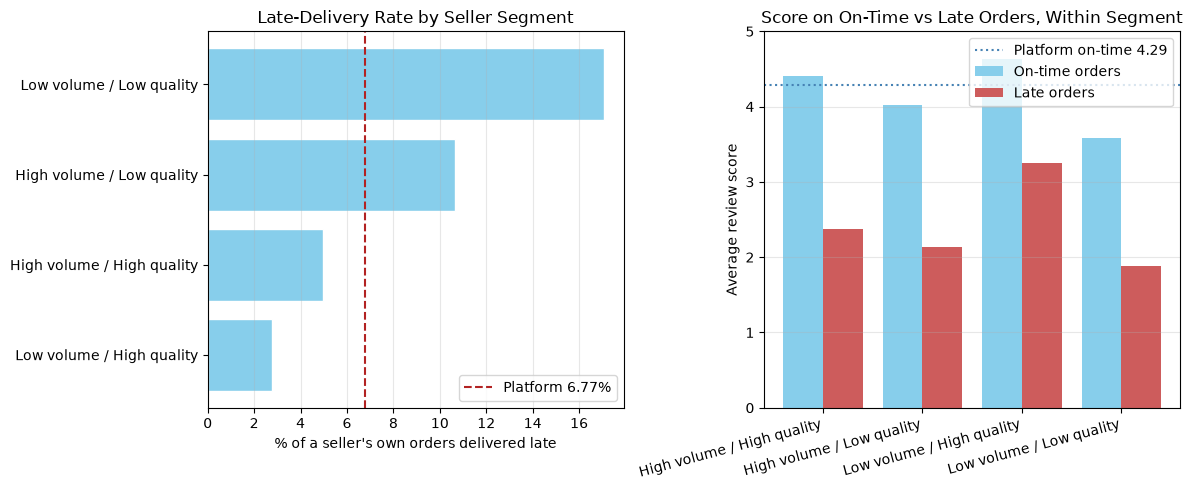

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ordered_segments = segment_late.sort_values('late_rate', ascending=True)
axes[0].barh(ordered_segments.index, ordered_segments['late_rate'] * 100, color='skyblue', edgecolor='white')
axes[0].axvline(platform_late_rate, color='firebrick', linestyle='--', label=f'Platform {platform_late_rate:.2f}%')
axes[0].set_title('Late-Delivery Rate by Seller Segment')
axes[0].set_xlabel("% of a seller's own orders delivered late")
axes[0].legend()
axes[0].grid(True, axis='x', alpha=0.3)

x_seg = np.arange(len(gap_check))
axes[1].bar(x_seg - 0.2, gap_check['ontime_score'], width=0.4, label='On-time orders', color='skyblue')
axes[1].bar(x_seg + 0.2, gap_check['late_score'], width=0.4, label='Late orders', color='indianred')
axes[1].axhline(platform_ontime_score, color='steelblue', linestyle=':', label=f'Platform on-time {platform_ontime_score:.2f}')
axes[1].set_xticks(x_seg, gap_check.index, rotation=15, ha='right')
axes[1].set_ylabel('Average review score')
axes[1].set_ylim(0, 5)
axes[1].set_title('Score on On-Time vs Late Orders, Within Segment')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## What This Means

Delivery is a real but only partial explanation: the risk segment is late on 10.6% of its orders against 5.0% for the high-volume/high-quality segment and 6.8% platform-wide, and its late orders are punished almost exactly as hard as everyone else's (a 1.89-point on-time-to-late drop versus 2.02 platform-wide) — so on-time delivery is not what is holding this group back. Even if every one of its 2,685 late orders had scored like a normal on-time order, the segment would only move from 3.86 to 4.05, recovering about 45% of its 0.43-point deficit against the high-quality segment, and the 88 risk sellers with a literally 0% late rate still average 3.64 against a platform on-time 4.29. The data therefore supports **a mix that leans seller-driven**: delivery timing is a genuine contributing factor worth fixing, but roughly 55% of the quality gap survives once delivery is removed — so the proposed Order & Seller Risk Score's attribution layer has to separate these two causes explicitly, because this segment alone generates 41% of all late orders on the platform while a naive score would book most of that as seller quality.